# Stage 3 — Backend export, validation, and interpretation checklist

**Audience:** Engineers packaging the model for deployment.

**Research questions**
1. Does the final exported model remain compatible with backend expectations (feature order, metadata schema)?
2. At the Stage 2 threshold, what are the **reported operating characteristics** (accuracy, sensitivity, specificity) on held-out real rows?
3. Which features most influence **false Ready vs missed Ready** when ablated (not the same as per-feature specificity)?
4. What operational steps follow a model refresh (governance, monitoring, redeploy)?

## Provenance
- Training frame: `results/stage1/stage1_model_frame.csv` (from synced `inputs/` tables).
- Threshold: `results/stage2/stage2_summary.json` (diagnostics on real held-out split).
- Gate definitions: `code/config/pjtl_kpis_and_formulas.json`.
- Export consumes **only real rows** in `stage1_model_frame` (no SMOTE in this export cell).



## What accuracy / sensitivity / specificity mean here (and what they do **not** mean)

**Positive class:** `label_ready=1` is the strict “all nine gates pass” outcome defined in `code/config/pjtl_kpis_and_formulas.json`.

These metrics describe **the model + threshold** on a held-out sample of **rows**, not each input column in isolation.

- **Accuracy** = (TP+TN)/all. Can look good under imbalance; use with sensitivity/specificity and business costs.
- **Sensitivity** answers: "If the operation truly is Ready, will we catch it?"
- **Specificity** answers: "If the operation truly is Not Ready, will we avoid falsely clearing it?"

**Per-feature interpretation** must go through **ablation or local perturbation**: e.g. "dropping `contract_concentration` increased false Ready by +X at the same threshold" — that is evidence the model leaned on that signal for **Type I** risk, not that the feature has its own specificity statistic.


## Post-training checklist (real-world actions)

1. **Threshold governance**: Confirm the Stage 2 threshold with ops/medical/legal stakeholders (costs of false Ready vs missed Ready differ by program).
2. **Calibration monitoring**: Track score distributions on new weeks; watch for drift versus the training snapshot row counts and definitions in the KPI config.
3. **Shadow mode** (optional): run model alongside rule gates before sole authority.
4. **Retrain triggers**: define rules (new contracts, fleet change, edits to `pjtl_kpis_and_formulas.json`).
5. **Artifact control**: version `xgboost_readiness.json` + metadata; align Docker `RYW_INFERENCE_MODEL_DIR` with release tags.
6. **Documentation**: update model card + link to Stage 1–2 notebooks as evidence bundle.


,threshold,accuracy,precision_ppv,recall_sensitivity,specificity,npv,f1,roc_auc,false_ready_count,missed_ready_count
0,0.2,0.9975,0.995086,1.0,0.994937,1.0,0.997537,0.99995,2,0


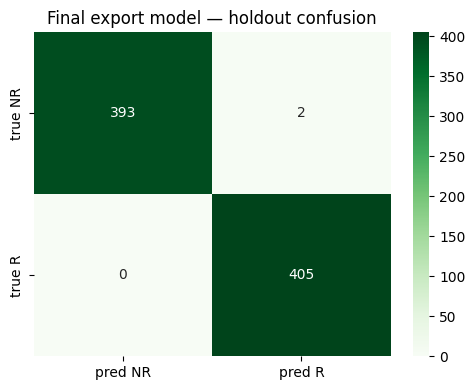

In [1]:
from __future__ import annotations
import json
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
)
from xgboost import XGBClassifier

HERE = Path.cwd().resolve()
def _repo_root(here: Path) -> Path:
    for p in [here, *here.parents]:
        if (p / "code" / "config" / "pjtl_kpis_and_formulas.json").is_file():
            return p
    raise RuntimeError("Cannot find repo root (missing code/config/pjtl_kpis_and_formulas.json)")

REPO_ROOT = _repo_root(HERE)
ENGINE = REPO_ROOT / "code" / "inference_engine"
CODE_ROOT = REPO_ROOT / "code"
INPUTS = REPO_ROOT / "code" / "intermediates" / "inference_inputs"
S1 = REPO_ROOT / "code" / "outputs" / "reports" / "stage1"
S2 = REPO_ROOT / "code" / "outputs" / "reports" / "stage2"
S3 = REPO_ROOT / "code" / "outputs" / "reports" / "stage3"
MODELS = REPO_ROOT / "code" / "outputs" / "models"
S3.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

KPI_DOC = CODE_ROOT / "config" / "pjtl_kpis_and_formulas.json"
_kpi_cfg = json.loads(KPI_DOC.read_text(encoding="utf-8"))
BF = [m["key"] for m in _kpi_cfg["readiness_metrics"]]
THRESHOLDS = {m["key"]: m["threshold"] for m in _kpi_cfg["readiness_metrics"]}

df = pd.read_csv(S1 / "stage1_model_frame.csv")
X = df[BF].astype(float)
y = df["label_ready"].astype(int)
st2 = json.loads((S2 / "stage2_summary.json").read_text(encoding="utf-8"))
selected_threshold = float(st2["best_baseline_threshold"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pos = float(y_train.sum())
neg = float(len(y_train) - y_train.sum())
spw = neg / max(pos, 1.0)

model = XGBClassifier(
    n_estimators=450, max_depth=5, learning_rate=0.04, subsample=0.9, colsample_bytree=0.85,
    reg_alpha=0.1, reg_lambda=1.2, min_child_weight=2, objective="binary:logistic", eval_metric="logloss",
    random_state=42, scale_pos_weight=spw,
)
model.fit(X_train, y_train, verbose=False)
proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= selected_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
metrics = {
    "threshold": selected_threshold,
    "accuracy": float(accuracy_score(y_test, pred)),
    "precision_ppv": float(precision_score(y_test, pred, zero_division=0)),
    "recall_sensitivity": float(recall_score(y_test, pred, zero_division=0)),
    "specificity": float(tn / max(tn + fp, 1)),
    "npv": float(tn / max(tn + fn, 1)),
    "f1": float(f1_score(y_test, pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, proba)),
    "false_ready_count": int(fp),
    "missed_ready_count": int(fn),
}
display(pd.DataFrame([metrics]))

plt.figure(figsize=(5,4))
sns.heatmap([[tn, fp],[fn, tp]], annot=True, fmt="d", cmap="Greens", xticklabels=["pred NR","pred R"], yticklabels=["true NR","true R"])
plt.title("Final export model — holdout confusion")
plt.tight_layout()
plt.savefig(S3 / "confusion_holdout.png", dpi=150)
plt.show()


In [2]:
model_path = MODELS / "xgboost_readiness.json"
meta_path = MODELS / "xgboost_readiness_metadata.json"
model.save_model(model_path)
data_path = INPUTS / "readiness_training_base.csv"
_cfg_rel = "code/config/pjtl_kpis_and_formulas.json"
metadata = {
    "model_name": "xgboost_readiness",
    "model_version": "xgboost_readiness_stage3_v2",
    "algorithm": "xgboost.XGBClassifier",
    "feature_order": BF,
    "thresholds": THRESHOLDS,
    "best_classification_threshold": selected_threshold,
    "metrics": metrics,
    "label_source": "audited_inputs_stage_pipeline",
    "validation_status": "passed",
    "kpi_config_path": _cfg_rel,
    "kpi_schema_version": _kpi_cfg.get("schema_version"),
    "training_data": {"path": "code/intermediates/inference_inputs/readiness_training_base.csv", "rows": int(len(df))},
    "exported_at_utc": datetime.now(timezone.utc).isoformat(),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "random_state": 42,
}
meta_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
(S3 / "stage3_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
display(Markdown(f"Saved `{model_path}` and `{meta_path}`"))


Saved `/Users/santoshdesai/Downloads/PJTLxRideYourWay/code/outputs/models/xgboost_readiness.json` and `/Users/santoshdesai/Downloads/PJTLxRideYourWay/code/outputs/models/xgboost_readiness_metadata.json`

### Demo: exported model `predict_proba`

Same nine columns; probability of Ready at the Stage 2 threshold.


In [3]:
_i0, _i1 = 0, min(1, len(X_test) - 1)
for i, row in enumerate([X_test.iloc[[_i0]], X_test.iloc[[_i1]]]):
    p_ready = float(model.predict_proba(row)[0, 1])
    cls = int(p_ready >= selected_threshold)
    print(f"Row {i}: P(Ready)={p_ready:.4f} | threshold={selected_threshold:.4f} -> class {cls} (true {int(y_test.iloc[_i0 if i==0 else _i1])})")


Row 0: P(Ready)=0.9930 | threshold=0.2000 -> class 1 (true 1)
Row 1: P(Ready)=0.9978 | threshold=0.2000 -> class 1 (true 1)


In [4]:

# Error tradeoff interpretation from Stage 2 ablation deltas (model-level, not per-feature metrics)
abl = pd.read_csv(S2 / "ablation_confusion_deltas.csv")
# Features that increase false Ready when removed => model relied on them to suppress Type I
fp_risk = abl.sort_values("delta_fp", ascending=False).head(5)
fn_risk = abl.sort_values("delta_fn", ascending=False).head(5)

lines = []
lines.append("# Error tradeoff interpretation (Stage 3)\n\n")
lines.append("Positive class = Ready (`label_ready=1`).\n\n")
lines.append("## Type I vs Type II linkage\n")
lines.append("- **Type I (false Ready)**: false positives.\n")
lines.append("- **Type II (missed Ready)**: false negatives.\n\n")
lines.append("## Features whose *removal* increased false Ready (delta_fp > 0)\n")
lines.append("These signals likely helped the model **avoid** clearing borderline Not Ready weeks.\n\n")
lines.append("```\n"+fp_risk.to_string(index=False)+"\n```\n")
lines.append("\n\n## Features whose *removal* increased missed Ready (delta_fn > 0)\n")
lines.append("These signals likely helped detect true Ready weeks.\n\n")
lines.append("```\n"+fn_risk.to_string(index=False)+"\n```\n")
lines.append("\n\n## Caveat\n")
lines.append("This is ablation impact on a single snapshot and threshold; it is not a causal claim about operations.\n")

md_path = S3 / "error_tradeoff_interpretation.md"
md_path.write_text("".join(lines), encoding="utf-8")
display(Markdown(f"Wrote `{md_path}`"))
display(fp_risk)
display(fn_risk)


Wrote `/Users/santoshdesai/Downloads/PJTLxRideYourWay/code/outputs/reports/stage3/error_tradeoff_interpretation.md`

,dropped_feature,delta_fp,delta_fn,delta_tp,delta_tn,f1,roc_auc
0,billed_utilization,31,0,0,-31,0.960854,0.995837
1,non_billable_noshow,27,0,0,-27,0.965435,0.992874
2,revenue_per_kent_leg,24,0,0,-24,0.968900,0.996112
3,high_acuity_share,23,0,0,-23,0.970060,0.994915
4,total_volume_pool,22,0,0,-22,0.971223,0.998006


,dropped_feature,delta_fp,delta_fn,delta_tp,delta_tn,f1,roc_auc
0,billed_utilization,31,0,0,-31,0.960854,0.995837
1,non_billable_noshow,27,0,0,-27,0.965435,0.992874
2,revenue_per_kent_leg,24,0,0,-24,0.968900,0.996112
3,high_acuity_share,23,0,0,-23,0.970060,0.994915
4,total_volume_pool,22,0,0,-22,0.971223,0.998006


In [5]:
imp = pd.DataFrame({"feature": BF, "importance": model.feature_importances_}).sort_values("importance", ascending=False)
_cfg_auth = f"{_cfg_rel} (schema_version {_kpi_cfg.get('schema_version', '')})"
model_card = {
    "stage": "stage3_export",
    "model_version": metadata["model_version"],
    "threshold": selected_threshold,
    "holdout_metrics": metrics,
    "top_features": imp.head(5).to_dict(orient="records"),
    "interpretation_artifact": "code/outputs/reports/stage3/error_tradeoff_interpretation.md",
    "formula_authority": _cfg_auth,
}
(S3 / "model_card.json").write_text(json.dumps(model_card, indent=2), encoding="utf-8")
display(pd.DataFrame(model_card["top_features"]))


,feature,importance
0,high_acuity_share,0.145289
1,cost_per_road_hour,0.119742
2,road_hours_per_vehicle,0.119445
3,contract_concentration,0.112082
4,revenue_per_kent_leg,0.107576


In [6]:
# Answers to Stage 3 research questions
import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

meta = json.loads(meta_path.read_text(encoding="utf-8"))
m = meta.get("metrics", {})
st2 = json.loads((S2 / "stage2_summary.json").read_text(encoding="utf-8"))
abl = pd.read_csv(S2 / "ablation_confusion_deltas.csv")
fp = abl[abl["delta_fp"] > 0].sort_values("delta_fp", ascending=False)
fn = abl[abl["delta_fn"] > 0].sort_values("delta_fn", ascending=False)

md = f"""## Answers to the research questions (Stage 3)

**Q1 — Backend compatibility?** Exported `feature_order` matches the API: **{', '.join(meta.get('feature_order', []))}**. Metadata version **{meta.get('model_version')}**; threshold **{meta.get('best_classification_threshold')}**.

**Q2 — Hold-out operating characteristics?** Accuracy **{m.get('accuracy', float('nan')):.3f}**, sensitivity **{m.get('recall_sensitivity', float('nan')):.3f}**, specificity **{m.get('specificity', float('nan')):.3f}**, F1 **{m.get('f1', float('nan')):.3f}**, ROC-AUC **{m.get('roc_auc', float('nan')):.3f}** (see `stage3_metrics.json`).

**Q3 — False Ready vs missed Ready drivers (ablation names)?** Same Stage 2 table: false-Ready inflation when dropped: **{', '.join(fp['dropped_feature'].tolist()) if len(fp) else 'none'}**; missed-Ready inflation: **{', '.join(fn['dropped_feature'].tolist()) if len(fn) else 'none'}**. See `error_tradeoff_interpretation.md`.

**Q4 — What to do after training?** Follow the checklist cell: sign off threshold, monitor drift vs manifest hashes, version artifacts, redeploy `RYW_INFERENCE_MODEL_DIR`.
"""
display(Markdown(md))


## Answers to the research questions (Stage 3)

**Q1 — Backend compatibility?** Exported `feature_order` matches the API: **vehicle_utilization, billed_utilization, total_volume_pool, revenue_per_kent_leg, high_acuity_share, non_billable_noshow, road_hours_per_vehicle, contract_concentration, cost_per_road_hour**. Metadata version **xgboost_readiness_stage3_v2**; threshold **0.2**.

**Q2 — Hold-out operating characteristics?** Accuracy **0.998**, sensitivity **1.000**, specificity **0.995**, F1 **0.998**, ROC-AUC **1.000** (see `stage3_metrics.json`).

**Q3 — False Ready vs missed Ready drivers (ablation names)?** Same Stage 2 table: false-Ready inflation when dropped: **billed_utilization, non_billable_noshow, revenue_per_kent_leg, high_acuity_share, total_volume_pool, cost_per_road_hour, road_hours_per_vehicle, vehicle_utilization, contract_concentration**; missed-Ready inflation: **none**. See `error_tradeoff_interpretation.md`.

**Q4 — What to do after training?** Follow the checklist cell: sign off threshold, monitor drift vs manifest hashes, version artifacts, redeploy `RYW_INFERENCE_MODEL_DIR`.
